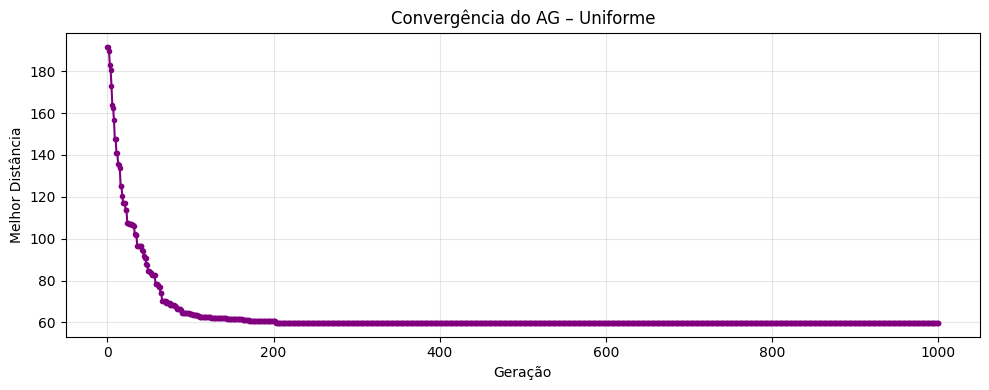

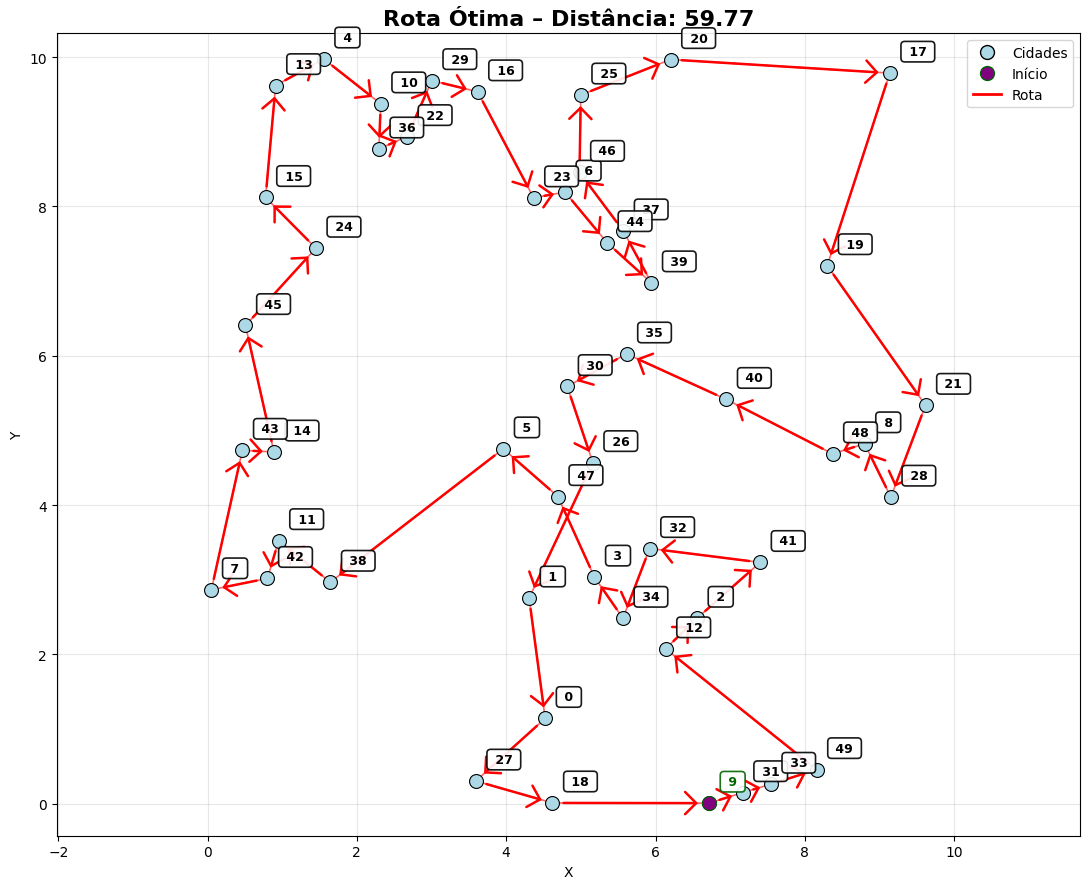

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D

# Lê arquivos
pontos = np.loadtxt("pontos_uniforme.csv", delimiter=",")
hist = pd.read_csv("evolucao.csv")
rota = np.loadtxt("melhor_rota.txt", dtype=int)

# 1. Convergência
plt.figure(figsize=(10,4))
plt.plot(hist['Geracao'], hist['MelhorDistancia'], 'o-', color='purple', markersize=3)
plt.title("Convergência do AG – Uniforme")
plt.xlabel("Geração"); plt.ylabel("Melhor Distância")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 2. Mapa + rota
plt.figure(figsize=(11,9))
x, y = pontos[:,0], pontos[:,1]
plt.scatter(x, y, c='lightblue', s=100, zorder=5, edgecolors='black', linewidth=0.8)
ini = rota[0]
plt.scatter(x[ini], y[ini], c='purple', s=100, zorder=5, edgecolors='darkgreen', linewidth=0.8)

for i, (xi, yi) in enumerate(pontos):
    offset = 0.2
    color = 'darkgreen' if i == ini else 'black'
    plt.text(xi + offset, yi + offset, f' {i} ', fontsize=9, fontweight='bold', color=color,
             ha='left', va='bottom',
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9, edgecolor=color, linewidth=1.2),
             zorder=7)

for i in range(len(rota)):
    i1, i2 = rota[i], rota[(i+1)%len(rota)]
    p1, p2 = pontos[i1], pontos[i2]
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r-', lw=1.2, alpha=0.6, zorder=3)
    arrow = FancyArrowPatch(posA=(p1[0], p1[1]), posB=(p2[0], p2[1]),
                            arrowstyle='->,head_length=1,head_width=1', color='red',
                            lw=1.8, mutation_scale=8, shrinkA=8, shrinkB=8, zorder=4)
    plt.gca().add_patch(arrow)

dist = hist['MelhorDistancia'].iloc[-1]
plt.title(f'Rota Ótima – Distância: {dist:.2f}', fontsize=16, fontweight='bold')
plt.xlabel('X'); plt.ylabel('Y'); plt.axis('equal'); plt.grid(alpha=0.3)

legend = [
    Line2D([0],[0], marker='o', color='w', label='Cidades', markerfacecolor='lightblue', markersize=10, markeredgecolor='black'),
    Line2D([0],[0], marker='o', color='w', label='Início', markerfacecolor='purple', markersize=10, markeredgecolor='darkgreen'),
    Line2D([0],[0], color='red', lw=2, label='Rota')
]
plt.legend(handles=legend, loc='upper right')
plt.tight_layout(); plt.show()# Instala g++ (compilador C++)
